In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("../data/telecom_churn_clean.csv")
print(df.head())

   customer_id telecom_partner gender  age              state     city  \
0            1    Reliance Jio      F   25          Karnataka  Kolkata   
1            2    Reliance Jio      F   55            Mizoram   Mumbai   
2            3        Vodafone      F   57  Arunachal Pradesh    Delhi   
3            4            BSNL      M   46         Tamil Nadu  Kolkata   
4            5            BSNL      F   26            Tripura    Delhi   

   pincode date_of_registration  num_dependents  estimated_salary  calls_made  \
0   755597           2020-01-01               4            124962          44   
1   125926           2020-01-01               2            130556          62   
2   423976           2020-01-01               0            148828          49   
3   522841           2020-01-01               1             38722          80   
4   740247           2020-01-01               2             55098          78   

   sms_sent  data_used  churn  
0        45          0  False  
1   

In [4]:
df = df.drop(columns=["customer_id","pincode"])
print(df.head())

  telecom_partner gender  age              state     city  \
0    Reliance Jio      F   25          Karnataka  Kolkata   
1    Reliance Jio      F   55            Mizoram   Mumbai   
2        Vodafone      F   57  Arunachal Pradesh    Delhi   
3            BSNL      M   46         Tamil Nadu  Kolkata   
4            BSNL      F   26            Tripura    Delhi   

  date_of_registration  num_dependents  estimated_salary  calls_made  \
0           2020-01-01               4            124962          44   
1           2020-01-01               2            130556          62   
2           2020-01-01               0            148828          49   
3           2020-01-01               1             38722          80   
4           2020-01-01               2             55098          78   

   sms_sent  data_used  churn  
0        45          0  False  
1        39       5973  False  
2        24        193   True  
3        25       9377   True  
4        15       1393  False  


In [5]:
print(df.dtypes)

telecom_partner           str
gender                    str
age                     int64
state                     str
city                      str
date_of_registration      str
num_dependents          int64
estimated_salary        int64
calls_made              int64
sms_sent                int64
data_used               int64
churn                    bool
dtype: object


In [6]:
df["date_of_registration"] = pd.to_datetime(df["date_of_registration"])


In [7]:
print(df.dtypes)

telecom_partner                    str
gender                             str
age                              int64
state                              str
city                               str
date_of_registration    datetime64[us]
num_dependents                   int64
estimated_salary                 int64
calls_made                       int64
sms_sent                         int64
data_used                        int64
churn                             bool
dtype: object


In [8]:
reference_date = df["date_of_registration"].max()
df["customer_tenure"] = (reference_date - df["date_of_registration"]).dt.days

df["year_of_registration"] = df["date_of_registration"].dt.year
df["month_of_registration"] = df["date_of_registration"].dt.month

df = df.drop(columns=["date_of_registration"])

print(df.head())

  telecom_partner gender  age              state     city  num_dependents  \
0    Reliance Jio      F   25          Karnataka  Kolkata               4   
1    Reliance Jio      F   55            Mizoram   Mumbai               2   
2        Vodafone      F   57  Arunachal Pradesh    Delhi               0   
3            BSNL      M   46         Tamil Nadu  Kolkata               1   
4            BSNL      F   26            Tripura    Delhi               2   

   estimated_salary  calls_made  sms_sent  data_used  churn  customer_tenure  \
0            124962          44        45          0  False             1219   
1            130556          62        39       5973  False             1219   
2            148828          49        24        193   True             1219   
3             38722          80        25       9377   True             1219   
4             55098          78        15       1393  False             1219   

   year_of_registration  month_of_registration  
0      

In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   telecom_partner        243553 non-null  str  
 1   gender                 243553 non-null  str  
 2   age                    243553 non-null  int64
 3   state                  243553 non-null  str  
 4   city                   243553 non-null  str  
 5   num_dependents         243553 non-null  int64
 6   estimated_salary       243553 non-null  int64
 7   calls_made             243553 non-null  int64
 8   sms_sent               243553 non-null  int64
 9   data_used              243553 non-null  int64
 10  churn                  243553 non-null  bool 
 11  customer_tenure        243553 non-null  int64
 12  year_of_registration   243553 non-null  int32
 13  month_of_registration  243553 non-null  int32
dtypes: bool(1), int32(2), int64(7), str(4)
memory usage: 22.5 MB
None


In [10]:
for col in ["telecom_partner","gender","state","city"]:
    print(df[col].nunique())

print(df["city"].unique())

4
2
28
6
<StringArray>
['Kolkata', 'Mumbai', 'Delhi', 'Chennai', 'Hyderabad', 'Bangalore']
Length: 6, dtype: str


In [11]:
df["gender"] = df["gender"].map({"M":0,"F":1})
print(df.head())

  telecom_partner  gender  age              state     city  num_dependents  \
0    Reliance Jio       1   25          Karnataka  Kolkata               4   
1    Reliance Jio       1   55            Mizoram   Mumbai               2   
2        Vodafone       1   57  Arunachal Pradesh    Delhi               0   
3            BSNL       0   46         Tamil Nadu  Kolkata               1   
4            BSNL       1   26            Tripura    Delhi               2   

   estimated_salary  calls_made  sms_sent  data_used  churn  customer_tenure  \
0            124962          44        45          0  False             1219   
1            130556          62        39       5973  False             1219   
2            148828          49        24        193   True             1219   
3             38722          80        25       9377   True             1219   
4             55098          78        15       1393  False             1219   

   year_of_registration  month_of_registration  
0

In [12]:
# df = pd.get_dummies(df,columns=["telecom_partner","state","city"],drop_first=True,dtype=int)
# print(df.head())
df.groupby("state")["churn"].mean().sort_values()


state
West Bengal          0.194004
Punjab               0.194251
Chhattisgarh         0.194307
Tripura              0.194804
Kerala               0.195301
Bihar                0.196340
Meghalaya            0.197490
Andhra Pradesh       0.198520
Arunachal Pradesh    0.198927
Maharashtra          0.199093
Tamil Nadu           0.199358
Goa                  0.199563
Gujarat              0.200232
Haryana              0.200343
Sikkim               0.200714
Uttar Pradesh        0.200755
Telangana            0.201059
Manipur              0.201133
Rajasthan            0.202171
Nagaland             0.202289
Odisha               0.202479
Assam                0.202995
Madhya Pradesh       0.203811
Himachal Pradesh     0.204100
Uttarakhand          0.204155
Mizoram              0.206468
Karnataka            0.207123
Jharkhand            0.211194
Name: churn, dtype: float64

In [13]:
df.groupby("city")["churn"].mean().sort_values()

city
Delhi        0.197499
Chennai      0.197551
Bangalore    0.200502
Kolkata      0.201569
Mumbai       0.201580
Hyderabad    0.204162
Name: churn, dtype: float64

In [14]:
df.groupby("telecom_partner")["churn"].mean().sort_values()

telecom_partner
BSNL            0.198607
Vodafone        0.199484
Reliance Jio    0.200154
Airtel          0.203661
Name: churn, dtype: float64

In [15]:
df["telecom_partner"].value_counts()

telecom_partner
Reliance Jio    61123
Airtel          60905
Vodafone        60802
BSNL            60723
Name: count, dtype: int64

In [16]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   telecom_partner        243553 non-null  str  
 1   gender                 243553 non-null  int64
 2   age                    243553 non-null  int64
 3   state                  243553 non-null  str  
 4   city                   243553 non-null  str  
 5   num_dependents         243553 non-null  int64
 6   estimated_salary       243553 non-null  int64
 7   calls_made             243553 non-null  int64
 8   sms_sent               243553 non-null  int64
 9   data_used              243553 non-null  int64
 10  churn                  243553 non-null  bool 
 11  customer_tenure        243553 non-null  int64
 12  year_of_registration   243553 non-null  int32
 13  month_of_registration  243553 non-null  int32
dtypes: bool(1), int32(2), int64(8), str(3)
memory usage: 22.5 MB
None


In [17]:
df = pd.get_dummies(df,columns=["telecom_partner","state","city"],drop_first=True,dtype=int)
print(df.head())

   gender  age  num_dependents  estimated_salary  calls_made  sms_sent  \
0       1   25               4            124962          44        45   
1       1   55               2            130556          62        39   
2       1   57               0            148828          49        24   
3       0   46               1             38722          80        25   
4       1   26               2             55098          78        15   

   data_used  churn  customer_tenure  year_of_registration  ...  \
0          0  False             1219                  2020  ...   
1       5973  False             1219                  2020  ...   
2        193   True             1219                  2020  ...   
3       9377   True             1219                  2020  ...   
4       1393  False             1219                  2020  ...   

   state_Telangana  state_Tripura  state_Uttar Pradesh  state_Uttarakhand  \
0                0              0                    0                  0  

In [18]:
# df = df.drop(columns=["state","city","telecom_partner"])
# print(df.head())

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 46 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   gender                        243553 non-null  int64
 1   age                           243553 non-null  int64
 2   num_dependents                243553 non-null  int64
 3   estimated_salary              243553 non-null  int64
 4   calls_made                    243553 non-null  int64
 5   sms_sent                      243553 non-null  int64
 6   data_used                     243553 non-null  int64
 7   churn                         243553 non-null  bool 
 8   customer_tenure               243553 non-null  int64
 9   year_of_registration          243553 non-null  int32
 10  month_of_registration         243553 non-null  int32
 11  telecom_partner_BSNL          243553 non-null  int64
 12  telecom_partner_Reliance Jio  243553 non-null  int64
 13  telecom_partner_Vodafone 

In [19]:
churn = df.pop("churn")
df["churn"] = churn

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 46 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   gender                        243553 non-null  int64
 1   age                           243553 non-null  int64
 2   num_dependents                243553 non-null  int64
 3   estimated_salary              243553 non-null  int64
 4   calls_made                    243553 non-null  int64
 5   sms_sent                      243553 non-null  int64
 6   data_used                     243553 non-null  int64
 7   customer_tenure               243553 non-null  int64
 8   year_of_registration          243553 non-null  int32
 9   month_of_registration         243553 non-null  int32
 10  telecom_partner_BSNL          243553 non-null  int64
 11  telecom_partner_Reliance Jio  243553 non-null  int64
 12  telecom_partner_Vodafone      243553 non-null  int64
 13  state_Arunachal Pradesh  

In [20]:
df["churn"] = df["churn"].map({True:1,False:0})

In [21]:
print(df["churn"])

0         0
1         0
2         1
3         1
4         0
         ..
243548    0
243549    0
243550    0
243551    0
243552    0
Name: churn, Length: 243553, dtype: int64


In [22]:
df["churn"].value_counts()

churn
0    194726
1     48827
Name: count, dtype: int64

In [23]:
X = df.drop(columns=["churn"])
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train_scaled = StandardScaler().fit_transform(X_train)
X_test_scaled = StandardScaler().fit_transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

Accuracy : 0.7995319332388988
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.49894092859389727


c:\Users\geeth.madhu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\geeth.madhu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [26]:
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

churn
0    38946
1     9765
Name: count, dtype: int64
churn
0    0.799532
1    0.200468
Name: proportion, dtype: float64


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[38946     0]
 [ 9765     0]]


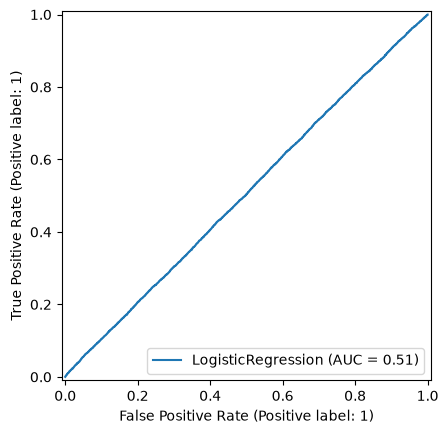

In [28]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(model,X_test_scaled,y_test)

plt.show()

In [29]:
print(model.predict(X_test_scaled).sum())

0


In [30]:
print(model.predict_proba(X_test_scaled)[:, 1].min())
print(model.predict_proba(X_test_scaled)[:, 1].max())
print(model.predict_proba(X_test_scaled)[:, 1].mean())

0.17835212748584792
0.22256188141570446
0.20046098257578837


In [31]:
print(X_train.shape)
print(X_test.shape)
print(X_train.dtypes.value_counts())

(194842, 45)
(48711, 45)
int64    43
int32     2
Name: count, dtype: int64


In [32]:
print(X_train.describe().T[["mean", "std", "min", "max"]])

                                      mean           std      min       max
gender                            0.401269      0.490156      0.0       1.0
age                              46.082498     16.449139     18.0      74.0
num_dependents                    1.996546      1.414247      0.0       4.0
estimated_salary              85052.296692  37531.267635  20000.0  149997.0
calls_made                       49.141196     29.274068      0.0     108.0
sms_sent                         24.029552     14.629394      0.0      53.0
data_used                      5005.080522   2925.377681      0.0   10991.0
customer_tenure                 609.706316    351.835579      0.0    1219.0
year_of_registration           2021.201651      0.981256   2020.0    2023.0
month_of_registration             6.123367      3.503183      1.0      12.0
telecom_partner_BSNL              0.249156      0.432525      0.0       1.0
telecom_partner_Reliance Jio      0.251111      0.433653      0.0       1.0
telecom_part

In [33]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train_scaled,y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(y_pred.sum())

print(y_prob.min())
print(y_prob.max())
print(y_prob.mean())

24233
0.46401819073206335
0.5331321479554119
0.4998970888401042


In [34]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.5024532446469997
Precision: 0.201419551850782
Recall   : 0.4998463901689708
F1 Score : 0.287134537325725
ROC-AUC  : 0.5058217097845169


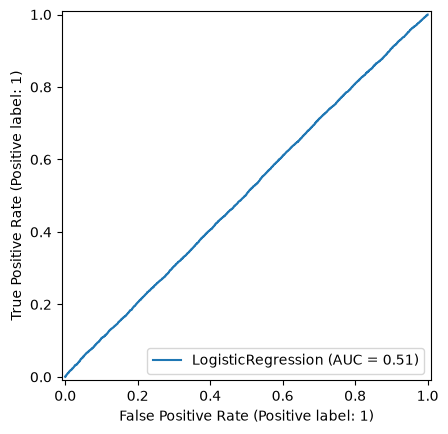

In [35]:
RocCurveDisplay.from_estimator(model,X_test_scaled,y_test)

plt.show()

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 100, random_state = 42, class_weight="balanced", n_jobs=-1)

rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]



In [37]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7965551928722465
Precision: 0.1888412017167382
Recall   : 0.004505888376856119
F1 Score : 0.008801760352070413
ROC-AUC  : 0.4986891193286152


In [38]:
print(
    df.groupby("churn")[
        [
            "age",
            "num_dependents",
            "estimated_salary",
            "calls_made",
            "sms_sent",
            "data_used",
            "customer_tenure"
        ]
    ].mean()
)

             age  num_dependents  estimated_salary  calls_made   sms_sent  \
churn                                                                       
0      46.070699        1.999302      85083.726934   49.094178  24.038336   
1      46.105167        1.990313      84771.527495   49.223585  23.925697   

         data_used  customer_tenure  
churn                                
0      5000.235757       610.290875  
1      5005.817642       608.839945  


In [39]:
print(df.corr(numeric_only=True)["churn"].sort_values())

estimated_salary               -0.003332
city_Delhi                     -0.003321
city_Chennai                   -0.003277
state_West Bengal              -0.003089
sms_sent                       -0.003086
state_Punjab                   -0.002981
state_Chhattisgarh             -0.002963
state_Tripura                  -0.002721
telecom_partner_BSNL           -0.002693
num_dependents                 -0.002543
state_Kerala                   -0.002493
state_Bihar                    -0.001982
customer_tenure                -0.001651
state_Meghalaya                -0.001435
telecom_partner_Vodafone       -0.001433
state_Arunachal Pradesh        -0.000748
state_Maharashtra              -0.000671
state_Tamil Nadu               -0.000539
telecom_partner_Reliance Jio   -0.000469
state_Goa                      -0.000440
state_Gujarat                  -0.000117
state_Haryana                  -0.000065
state_Sikkim                    0.000113
state_Uttar Pradesh             0.000134
state_Telangana 

In [40]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.799470345507175
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.501334799461983


Index(['gender', 'age', 'num_dependents', 'estimated_salary', 'calls_made',
       'sms_sent', 'data_used', 'customer_tenure', 'year_of_registration',
       'month_of_registration', 'telecom_partner_BSNL',
       'telecom_partner_Reliance Jio', 'telecom_partner_Vodafone',
       'state_Arunachal Pradesh', 'state_Assam', 'state_Bihar',
       'state_Chhattisgarh', 'state_Goa', 'state_Gujarat', 'state_Haryana',
       'state_Himachal Pradesh', 'state_Jharkhand', 'state_Karnataka',
       'state_Kerala', 'state_Madhya Pradesh', 'state_Maharashtra',
       'state_Manipur', 'state_Meghalaya', 'state_Mizoram', 'state_Nagaland',
       'state_Odisha', 'state_Punjab', 'state_Rajasthan', 'state_Sikkim',
       'state_Tamil Nadu', 'state_Telangana', 'state_Tripura',
       'state_Uttar Pradesh', 'state_Uttarakhand', 'state_West Bengal',
       'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Kolkata',
       'city_Mumbai', 'churn'],
      dtype='str')

In [51]:

df[df["telecom_partner_BSNL"] == True]["churn"].value_counts()

churn
0    48663
1    12060
Name: count, dtype: int64